# Subarray

A subarray is a contiguous range of array elements from index location `i` to `i+k`, that is, `a[i: i+k]`.

**Example**: `[10, 20, 30, 40]`

```
Subarray of length 1: [10], [20], [30], [40], [50]
Subarray of length 2: [10, 20], [20, 30], [30, 40], [40, 50]
Subarray of length 3: [10, 20, 30], [20, 30, 40], [300, 40, 50]
Subarray of length 4: [10, 20, 30, 40], [20, 30, 40, 50]
Subarray of length 5: [10, 20, 30, 40]

```

# Hashmap

It is a data structure that is used to store key-value pairs and is efficient for data retrieval.

**Example**: `[10, 20, 30, 40]`

Here, list elements are key, and the index is the value.

```python
map[10] = 0
map[20] = 1
map[30] = 2
map[40] = 3
map[50] = 4
```

# Problem 1: Target Sum

Given an unsorted array of integers, find a subarray that adds to a given number. If there is more than one subarray with the sum of the given number, print any of them.

**Examples:** 

**Input**: `arr[] = {1, 4, 20, 3, 10, 5}`, `targetsum = 33`

**Output**: Sum found between indexes `2` and `4`.

**Explanation**: Sum of elements between indices `2` and `4` is `20 + 3 + 10 = 33`

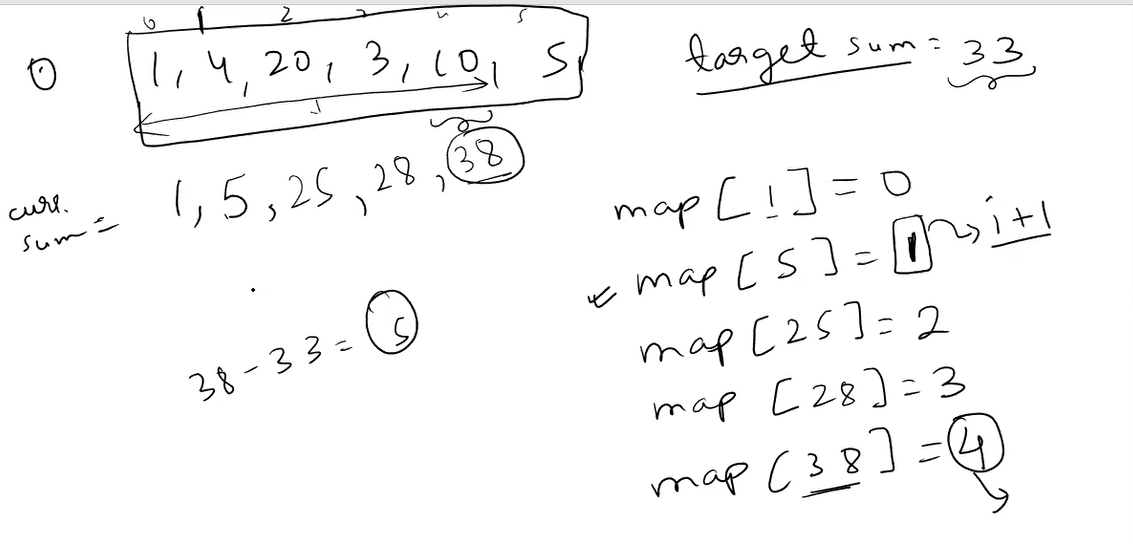

## Solution 1

In [1]:
def subarray_sum(arr, target_sum):
    # current_sum to keep track of the cumulative sum at each index
    current_sum = 0
    start_index = 0
    end_index = -1

    # map to store cumulative sum at each index
    map = {}

    for i in range(len(arr)):
        # Calculate current sum
        current_sum = current_sum + arr[i];

        # check whether cur_sum - sum = 0
        # if 0, it means the subarray is starting from index 0
        # so stop
        if (current_sum - target_sum) == 0:
            start_index = 0
            end_index = i
            break

        # if hashMap already has the current_sum value
        # means we already have a subarray with the sum
        # so stop
        if (current_sum - target_sum) in map:
            # get the index and add 1 to get the starting index
            start_index = map[current_sum - target_sum] + 1
            end_index = i
            break

        # current sum is still less than target sum
        # store current sum in hashMap with current index as value
        map[current_sum] = i

    if end_index == -1:
        print("No subarray with given target sum exists")
    else:
        print(f"Sum found between indexes {start_index} and {end_index}")


arr = [1, 4, 20, 3, 10, 5]
target_sum = 33

subarray_sum(arr, target_sum)


Sum found between indexes 2 and 4


**Time Complexity**: `O(n)`

**Space Complexity**: `O(n)`

# Problem 2: Largest Subarray with equal 0's & 1's

Given an array containing only 0's and 1's, find the largest subarray that contains an equal no of 0's and 1's.

**Input**: `arr[] = [0, 0, 1, 1, 0]`

**Output**: `0 to 3` Or `1 to 4`

> **TRICK**:
> * Replace 0's with -1's and try to find a subarray with target_sum = 0, and also track the length of the subarray to find the largest subarray.
> * Also note the process of how it finds the largest subarray, that is important

## Soultion 2:

In [2]:
def largest_subarray_equal_zeros_ones(arr):

    # Replace 0's with -1's in the input array to decompose the problem to a target_sum=0 problem
    for i in range(len(arr)):
        if arr[i] == 0:
            arr[i] = -1

    # current_sum to keep track of the cumulative sum at each index
    current_sum = 0
    start_index = 0
    end_index = -1

    # To track the largest length subarray
    max_length = 0

    # map to store cumulative sum at each index
    map = {}

    for i in range(len(arr)):
        # Calculate current sum
        current_sum = current_sum + arr[i];

        # check whether cur_sum = 0
        # if 0, it means the subarray is starting from index 0
        if current_sum == 0:
            start_index = 0
            end_index = i
            max_length = i + 1 # calculate max_length

        # If hashMap already has the current_sum value, it means we already have a subarray with the current_sum.
        # We have to discard elements till that index to get the target sum as 0
        # Note that map[current_sum] gives the index that we have to discard from the current index to get the subarray of target sum as 0
        # Also checks if max_length is less than the new subarray length.
        # if both conditions are satisfied, then we found the new largest subarray whose target sum is 0.
        if current_sum in map and max_length < (i - map[current_sum]): # i - map[current_sum] -> calculates the length of the array
            # update max_length
            max_length = i - map[current_sum]
            start_index = map[current_sum ] + 1
            end_index = i
        else:
            # store current sum in hashMap with current index as value, which is not there in the hashmap
            map[current_sum] = i

    if end_index == -1:
        print("No subarray with equal 0's & 1's")
    else:
        print(f"Largest subarray with equal 0's & 1's of length {max_length} is found between indexes {start_index} and {end_index}")


arr = [0, 0, 1, 1, 0]
largest_subarray_equal_zeros_ones(arr)

arr = [1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1]
largest_subarray_equal_zeros_ones(arr)

Largest subarray with equal 0's & 1's of length 4 is found between indexes 0 and 3
Largest subarray with equal 0's & 1's of length 6 is found between indexes 2 and 7


**Time Complexity**: `O(n)`

**Space Complexity**: `O(n)`

# Problem 3: Largest Subarray with equal odd & even

Given an integer array arr[], the task is to find the length of the longest subarray with an equal number of odd and even elements.

**Input**: `arr[] = [1, 2, 1, 2]`

**Output**: `4`

**Explanation**: 
* Subarrays in the given array are - `{{1}, {1, 2}, {1, 2, 1}, {1, 2, 1, 2}, {2}, {2, 1}, {2, 1, 2}, {1}, {1, 2}, {2}}`
* where the length of the longest subarray with an equal number of even and odd elements is **4** – `{1, 2, 1, 2}`

> **TRICK**:
> * Replace 0's with -1's and try to find a subarray with target_sum = 0, and also track the length of the subarray to find the largest subarray.
> * Also note the process of how it finds the largest subarray, that is important

## Solution 3

In [3]:
def largest_subarray_equal_odds_evens(arr):

    # Replace 1's with -1's  and 2's with 1's in the input array to decompose the problem to target_sum=0 problem
    for i in range(len(arr)):
        if arr[i] % 2 == 0:
            arr[i] = 1
        else:
            arr[i] = -1

    # current_sum to keep track of cumulative sum at each index
    current_sum = 0
    start_index = 0
    end_index = -1

    # To track the largest length subarray
    max_length = 0

    # map to store cumulative sum at each index
    map = {}

    for i in range(len(arr)):
        # Calculate current sum
        current_sum = current_sum + arr[i];

        # check whether cur_sum = 0
        # if 0, it means the sub array is starting from index 0
        if current_sum == 0:
            start_index = 0
            end_index = i
            max_length = i + 1 # calculate max_length

        # if hashMap already has the current_sum value
        # means we already have a subarray with the current_sum
        # and also checks if max_length is less than new subarray length
        if current_sum in map and max_length < (i - map[current_sum]): # i - map[current_sum] -> calculates the length of the array
            # update max_length
            max_length = i - map[current_sum]
            start_index = map[current_sum ] + 1
            end_index = i
        else:
            # store current sum in hashMap with current index as value, which is not there in the hashmap
            map[current_sum] = i

    if end_index == -1:
        print("No subarray with equal odd's & even's")
    else:
        print(f"Largest subarray with equal odd's & even's of length {max_length} is found between indexes {start_index} and {end_index}")


arr = [1, 2, 1, 2]
largest_subarray_equal_odds_evens(arr)

arr = [1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1]
largest_subarray_equal_odds_evens(arr)


Largest subarray with equal odd's & even's of length 4 is found between indexes 0 and 3
Largest subarray with equal odd's & even's of length 6 is found between indexes 2 and 7


**Time Complexity**: `O(n)`

**Space Complexity**: `O(n)`

# Problem 4: Majority element - element with frequency N/2 in an array of N elements

Find the majority element in the array. A majority element in an array A[] of size n is an element that appears more than n/2 times (and hence there is at most one such element).

**Input**: `A[]=[3, 3, 4, 2, 4, 4, 2, 4, 4]`

**Output**: `4`

**Explanation**: The frequency of `4` is `5`, which is greater than half of the size of the array.

## Pattern: “Voting / Cancelation” (Boyer–Moore)

**Core idea:** If you pair each occurrence of the majority element with a different element, all non-majority elements can be canceled out, and the majority element still remains because it appears more than the sum of all other elements.

**How it works (Intuition):**

```
Maintain a candidate and a count.

Traverse the array:
    * If count == 0, choose the current element as the new candidate.
    * If the current element equals the candidate, increment count.
    * Else, decrement the count.
```
* After one pass, the **candidate** is the **only possible majority element**.
* **Important**: **Do a second pass to verify** the candidate actually occurs more than n/2 times (because the array might have no majority).

**Why it works:**
* Every time you decrement (cancel) the count, you are effectively pairing one candidate with one distinct non-candidate.
* Since the true majority occurs more than n/2 times, it survives all cancellations.

**Time & Space Complexity:**
* Time: `O(n)`
* Space: `O(1)`

## Solution 4

In [4]:
"""
Function to print Majority Element
"""
def printMajorityElement(arr):
    # Find the candidate for Majority
    candiate = findCandidateElement(arr)
    # Print the candidate if it is Majority
    if isCanddiateMajorityElement(arr,candiate):
        print(f"Majority Element = {candiate}")
    else:
        print("No Majority Element Present.")


"""
Function to check if the candidate occurs more than n/2 times
"""
def isCanddiateMajorityElement(arr, candidate):
    length = len(arr)/2
    if arr.count(candidate) > length:
        return True
    else:
        return False


"""
Function to find the candidate for Majority 
"""
def findCandidateElement(arr):
    candidate = arr[0]
    count= 1
    for i in range(1,len(arr)):
        if arr[i] == candidate:
            count = count + 1
        else:
            count = count - 1

        if count == 0:
            candidate = arr[i]
            count = 1

    return candidate



arr = [3, 3, 4, 2, 4, 4, 2, 4, 4]
printMajorityElement(arr)

Majority Element = 4
